# 📊 01 — Pré-Processamento e Análise Exploratória

Neste notebook vamos:
1. Explorar o dataset de imagens térmicas (distribuição, dimensões, amostras visuais).
2. Validar integridade das imagens (detectar corrompidas).
3. Aplicar as transformações canônicas DINOv2 (resize 224×224, normalização ImageNet).
4. Gerar e salvar os splits train/val/test como tensores `.pt`.

---
## 1. Dependências

In [1]:
from __future__ import annotations

import sys
import logging
from pathlib import Path
from collections import Counter

import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import DataLoader, random_split

# Adicionar src/ ao path para importar nossos módulos
sys.path.insert(0, str(Path.cwd().parent))

from src.config import DINOv2Config
from src.transforms import build_transforms
from src.dataset import ThermalImageDataset, safe_collate_fn

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.14.0+cpu
CUDA disponível: False


---
## 2. Configuração

Todos os parâmetros ficam centralizados na dataclass `DINOv2Config`.
Ajuste o `data_dir` se necessário.

In [2]:
config = DINOv2Config(
    data_dir=Path("../data/raw"),
    image_size=224,
    batch_size=32,
    num_workers=0,  # 0 para debugging no notebook
)

print(config)

DINOv2Config(data_dir=WindowsPath('../data/raw'), image_size=224, patch_size=14, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225), batch_size=32, num_workers=0, pin_memory=True, device='cuda', supported_extensions=('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'))


---
## 3. Análise Exploratória do Dataset (EDA)

In [3]:
# Carregar o dataset SEM transformações (imagens brutas para análise)
raw_dataset = ThermalImageDataset(config, transform=None)

print(f"Total de imagens: {len(raw_dataset)}")
print(f"Classes encontradas: {raw_dataset.classes}")
print(f"Mapeamento classe → índice: {raw_dataset.class_to_idx}")

INFO: Indexadas 895 imagens em 5 classes de '..\data\raw'.


Total de imagens: 895
Classes encontradas: ['Circuit Breakers', 'Disconnectors', 'Power Transformers', 'Surge Arresters', 'Wave Traps']
Mapeamento classe → índice: {'Circuit Breakers': 0, 'Disconnectors': 1, 'Power Transformers': 2, 'Surge Arresters': 3, 'Wave Traps': 4}


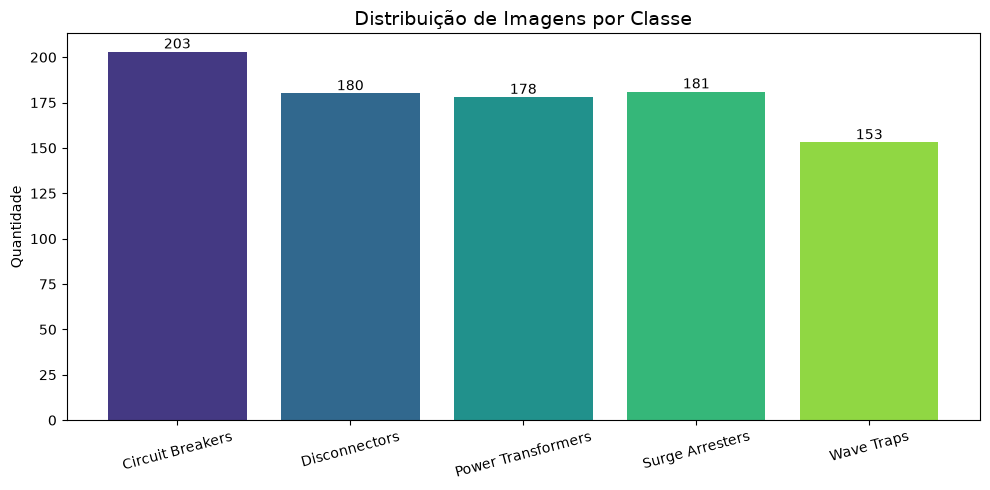

In [4]:
# Distribuição de imagens por classe
labels = [label for _, label in raw_dataset.samples]
class_counts = Counter(labels)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [raw_dataset.classes[i] for i in sorted(class_counts.keys())],
    [class_counts[i] for i in sorted(class_counts.keys())],
    color=sns.color_palette("viridis", len(raw_dataset.classes)),
)
ax.set_title("Distribuição de Imagens por Classe", fontsize=14)
ax.set_ylabel("Quantidade")
ax.bar_label(bars)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

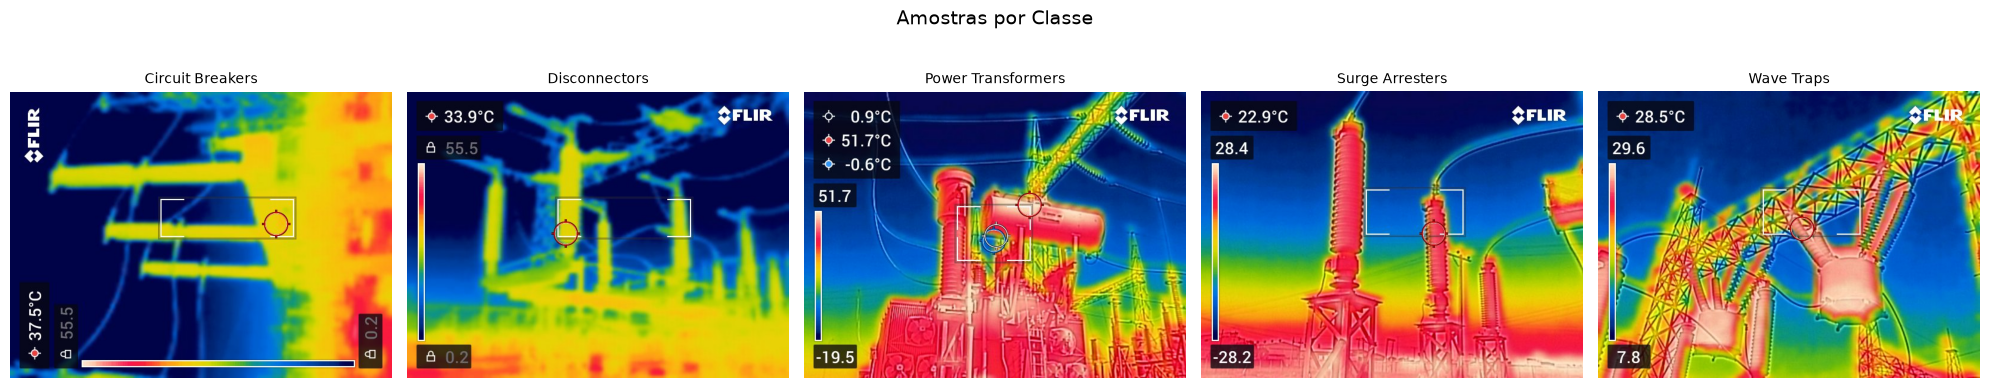

In [5]:
# Amostras visuais (1 por classe)
fig, axes = plt.subplots(1, len(raw_dataset.classes), figsize=(20, 4))

for cls_idx, cls_name in enumerate(raw_dataset.classes):
    # Pegar a primeira imagem dessa classe
    for img_path, label in raw_dataset.samples:
        if label == cls_idx:
            img = Image.open(img_path).convert("RGB")
            axes[cls_idx].imshow(img)
            axes[cls_idx].set_title(cls_name, fontsize=10)
            axes[cls_idx].axis("off")
            break

plt.suptitle("Amostras por Classe", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# Verificar dimensões das imagens no dataset
widths, heights = [], []
corrupted = []

for img_path, _ in raw_dataset.samples:
    try:
        with Image.open(img_path) as img:
            img.load()
            w, h = img.size
            widths.append(w)
            heights.append(h)
    except Exception as e:
        corrupted.append((str(img_path), str(e)))

print(f"Imagens válidas: {len(widths)}")
print(f"Imagens corrompidas: {len(corrupted)}")
if corrupted:
    for path, err in corrupted:
        print(f"  ⚠️ {path}: {err}")

print(f"\nDimensões — Largura: min={min(widths)}, max={max(widths)}, média={np.mean(widths):.0f}")
print(f"Dimensões — Altura:  min={min(heights)}, max={max(heights)}, média={np.mean(heights):.0f}")

Imagens válidas: 893
Imagens corrompidas: 2
  ⚠️ ..\data\raw\Power Transformers\FLIR1076.jpg: broken data stream when reading image file
  ⚠️ ..\data\raw\Power Transformers\FLIR1080.jpg: broken data stream when reading image file

Dimensões — Largura: min=640, max=640, média=640
Dimensões — Altura:  min=480, max=480, média=480


---
## 4. Transformações DINOv2

Pipeline canônico: Resize bicúbico → ToTensor → Normalize (ImageNet).

In [7]:
transform = build_transforms(config)
dataset = ThermalImageDataset(config, transform=transform)

# Sanity check com uma amostra
sample = dataset[0]
if sample is not None:
    tensor, label, path = sample
    print(f"Tensor shape: {tensor.shape}")
    print(f"Dtype: {tensor.dtype}")
    print(f"Pixel range: [{tensor.min():.3f}, {tensor.max():.3f}]")
    print(f"Label: {label} ({dataset.classes[label]})")
    print(f"Path: {path}")

INFO: Indexadas 895 imagens em 5 classes de '..\data\raw'.


Tensor shape: torch.Size([3, 224, 224])
Dtype: torch.float32
Pixel range: [-2.118, 2.640]
Label: 0 (Circuit Breakers)
Path: ..\data\raw\Circuit Breakers\FLIR2296.jpg


---
## 5. Geração dos Splits (Train / Val / Test)

Divisão reprodutível 70% / 15% / 15%.

In [8]:
torch.manual_seed(42)

total = len(dataset)
train_len = int(0.70 * total)
val_len = int(0.15 * total)
test_len = total - train_len - val_len

train_ds, val_ds, test_ds = random_split(dataset, [train_len, val_len, test_len])

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 626 | Val: 134 | Test: 135


In [9]:
from tqdm import tqdm

def save_split(split_dataset, name: str, output_dir: Path):
    """Processa e salva um split como arquivo .pt."""
    loader = DataLoader(
        split_dataset, batch_size=32, shuffle=False,
        num_workers=0, collate_fn=safe_collate_fn
    )

    all_tensors, all_labels = [], []
    for batch in tqdm(loader, desc=f"Salvando {name}"):
        if batch is None:
            continue
        images, labels, _ = batch
        all_tensors.append(images)
        all_labels.append(labels)

    if not all_tensors:
        print(f"⚠️ Split {name} vazio!")
        return

    tensors = torch.cat(all_tensors)
    labels = torch.cat(all_labels)

    output_dir.mkdir(parents=True, exist_ok=True)
    output_file = output_dir / f"{name}.pt"
    torch.save({"images": tensors, "labels": labels, "classes": dataset.classes}, output_file)
    print(f"✅ {output_file} | Shape: {tensors.shape}")


output_dir = Path("../data/processed")
save_split(train_ds, "train", output_dir)
save_split(val_ds, "val", output_dir)
save_split(test_ds, "test", output_dir)

Salvando train:   0%|          | 0/20 [00:00<?, ?it/s]

Salvando train:   5%|▌         | 1/20 [00:00<00:03,  5.37it/s]

Salvando train:  10%|█         | 2/20 [00:00<00:03,  5.52it/s]

Salvando train:  15%|█▌        | 3/20 [00:00<00:03,  5.52it/s]

Salvando train:  20%|██        | 4/20 [00:00<00:02,  5.59it/s]

...

Salvando test:  40%|████      | 2/5 [00:00<00:00,  5.28it/s]

Salvando test:  60%|██████    | 3/5 [00:00<00:00,  5.43it/s]

Salvando test:  80%|████████  | 4/5 [00:00<00:00,  5.45it/s]

Salvando test: 100%|██████████| 5/5 [00:00<00:00,  6.35it/s]

✅ ..\data\processed\test.pt | Shape: torch.Size([135, 3, 224, 224])


---
## 6. Verificação Final

Carregando o split de treino salvo para confirmar integridade.

In [10]:
data = torch.load(output_dir / "train.pt", weights_only=False)

print(f"Images shape: {data['images'].shape}")
print(f"Labels shape: {data['labels'].shape}")
print(f"Classes: {data['classes']}")
print(f"Distribuição: {Counter(data['labels'].tolist())}")

Images shape: torch.Size([626, 3, 224, 224])
Labels shape: torch.Size([626])
Classes: ['Circuit Breakers', 'Disconnectors', 'Power Transformers', 'Surge Arresters', 'Wave Traps']
Distribuição: Counter({0: 150, 2: 125, 1: 123, 3: 123, 4: 105})
